# ***Supervisor Agent***

In [1]:
from dotenv import load_dotenv
load_dotenv
import os
from langchain_groq import ChatGroq

In [2]:
os.environ["GROQ_API_KEY"] = os.environ["GROQ_API_KEY"]
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "Supervisor Agent Experiments"

llm = ChatGroq(model="qwen/qwen3-32b")

In [3]:
llm.invoke("Teine")

AIMessage(content='<think>\nOkay, the user wrote "Teine." Let me break this down.\n\nFirst, "Teine" is a short phrase in Estonian, and it translates to "Another" in English. Since the user didn\'t specify a question or request, I need to figure out the context. They might be looking for information, a translation, or maybe they want to continue a conversation in Estonian.\n\nI should consider possible scenarios. If they\'re learning Estonian, they might want to know how to use "teine" in a sentence. Alternatively, they could be asking about synonyms or related words. Since the input is minimal, it\'s safer to ask for clarification rather than assume.\n\nI should respond in a friendly and helpful manner, inviting them to provide more details. Maybe they need help with a specific context where "teine" is used. Let me make sure my response is open-ended so they can specify further.\n</think>\n\nYou wrote "Teine," which means "another" in Estonian. How can I assist you further? Are you loo

## **Tools**
- Tvili Search

In [4]:
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [5]:
from langchain_tavily import TavilySearch

search_tool = TavilySearch(
    max_results=3,
    topic="general"
)

search_tool.invoke("which agent pattern is best in between network patten, and supervisor pattern?")

{'query': 'which agent pattern is best in between network patten, and supervisor pattern?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': 'Agentic AI on AWS, the design patterns and considerations',
   'url': 'https://community.aws/content/2qlet7NAUR02ygnurN1O74CIwTN/agentic-ai-framework-on-aws-the-design-patterns-and-considerations',
   'content': 'Below diagram is an example of supervised agents based multi-agent pattern, where supervisor agent handles orchestration, governance, and routing for the two mortgage agents and a knowledge base.',
   'score': 0.507251,
   'raw_content': None},
  {'title': 'Scheduler Agent Supervisor pattern - Azure Architecture Center',
   'url': 'https://learn.microsoft.com/en-us/azure/architecture/patterns/scheduler-agent-supervisor',
   'content': "Scheduler Agent Supervisor pattern - Azure Architecture Center | Microsoft Learn If the steps in the workflow being run by the Scheduler use several services and resourc

## **Convert REPL into the tool**

In [6]:
code = """
x = 10
y = x+4
print(y)
"""

In [7]:
from langchain_experimental.utilities import PythonREPL
repl = PythonREPL()

In [8]:
repl.run(code)

Python REPL can execute arbitrary code. Use with caution.


'14\n'

In [9]:
from langchain.tools import tool
from typing import Annotated

@tool
def python_repl_tool(code: Annotated[str, "This is the user code in (str) format and its use for to generate the Chart."]):
    """Use this to execute the code and do math. if you want to see the output of the file please use print `print(...)`. This is visible to the user"""
    
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"faild to executie the code and the error is: {str(e)}"
    
    result_str = f"Successfully executed: \n\`\`\`python\n{code}\n\`\`\`\`\nStdout: {result}"
    return result_str
    

<>:13: SyntaxWarning: invalid escape sequence '\`'
<>:13: SyntaxWarning: invalid escape sequence '\`'
<>:13: SyntaxWarning: invalid escape sequence '\`'
<>:13: SyntaxWarning: invalid escape sequence '\`'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5416\2600667318.py:13: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed: \n\`\`\`python\n{code}\n\`\`\`\`\nStdout: {result}"
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5416\2600667318.py:13: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed: \n\`\`\`python\n{code}\n\`\`\`\`\nStdout: {result}"


In [10]:
response = python_repl_tool.invoke(
    {
        "code": code
    }
)
print(response)

Successfully executed: 
\`\`\`python

x = 10
y = x+4
print(y)

\`\`\`\`
Stdout: 14



In [11]:
members = ["researcher", "coder"]

In [12]:
options = members + ["FINISH"]
options

['researcher', 'coder', 'FINISH']

In [13]:
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel
class Router(TypedDict):
    """Based on the question its decide next what node will be execute"""
    next = Literal["researcher", "coder", "FINISH"]

In [14]:
from langgraph.graph import START, END, StateGraph,MessagesState

class State(MessagesState):
    next: str

In [15]:
system_prompt = f"""
    You are a supervisor, tasked with managing a conversation between the following workers: {members}.
    Given the following user request, respond with the worker to act next.
    Each worker will perform a task and respond with their results and status.
    when finished, respond with FINISH.
"""

## **Now time to build Agent**

In [16]:
# llm = ChatGroq(model=os.getenv("LLAMA_MODEL"))
# llm.invoke("Test line")

In [ ]:
# llm_with_structured_op = llm.with_structured_output(Router)
# response = llm_with_structured_op.invoke("write a prime number python code")
# response

In [18]:
from typing import Literal
from pydantic import BaseModel

class Router(BaseModel):
    """Based on the question, decide what node will be executed next."""
    next: Literal["researcher", "coder", "FINISH"]

llm_with_structured_op = llm.with_structured_output(Router)
response = llm_with_structured_op.invoke("write a prime number python code")
print(response)


next='coder'


In [19]:
from langgraph.types import Command

def supervisor_agent(state: State) -> Command[Literal["researcher", "coder", "__end__"]]:
    print("--Supervisor--")
    messages = [
        {
            "role": "system",
            "content": system_prompt
        },
    ] + state["messages"]
    
    print("hare-1")
    llm_with_structured_op = llm.with_structured_output(Router)
    response = llm_with_structured_op.invoke(messages)

    # print(response)
    goto = response.next
    
    print("*****************Below is my GOTO*******************")
    print(goto)
    
    if goto == "FINISH":
        goto =  END
    
    return Command(update={"next": goto}, goto=goto)
    
    

In [20]:
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import HumanMessage

def research_node(state: State) -> Command[Literal["supervisor"]]:
    research_agent =  create_react_agent(
        llm,
        tools=[search_tool],
        prompt="You are a researcher. DO NOT do any math."
    )
    response = research_agent.invoke(state)
    
    return Command(
        goto="supervisor",
        update = {
            "messages": [
                HumanMessage(content=response["messages"][-1].content, name="researcher")
            ]
        }
    )

In [21]:
def coder_node(state: State) -> Command[Literal["supervisor"]]:
    coder_agent =  create_react_agent(
        llm,
        tools=[python_repl_tool],
        prompt="You are a researcher. DO NOT do any math."
    )
    response = coder_agent.invoke(state)
    
    return Command(
        goto="supervisor",
        update = {
            "messages": [
                HumanMessage(content=response["messages"][-1].content, name="coder")
            ]
        }
    )

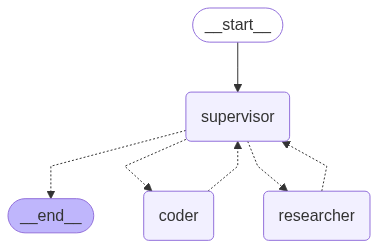

In [22]:
graph = StateGraph(State)

graph.add_node("supervisor", supervisor_agent)
graph.add_node("researcher", research_node)
graph.add_node("coder", coder_node)

graph.add_edge(START, "supervisor")

app = graph.compile()
app

In [ ]:
input = {"messages": ["can you write prime number python code.?"]}

for m in app.stream(input, stream_mode="values"):
    m["messages"][-1].pretty_print()

================================ Human Message =================================

can you write prime number python code.?
--Supervisor--
hare-1
*****************Below is my GOTO*******************
coder
================================ Human Message =================================

can you write prime number python code.?
================================ Human Message =================================
Name: coder

Here is the Python code for generating prime numbers up to 50, along with its explanation:

```python
def is_prime(n):
    if n < 2:
        return False
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0:
            return False
    return True

# Generate primes up to 50
primes = [num for num in range(2, 51) if is_prime(num)]
print(primes)
```

**Output:**
```
[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47]
```

**How it works:**
1. `is_prime(n)` checks if a number is prime by testing divisibility up to √n
2. The list comprehension filters numbers fr

In [33]:
input = {"messages": ["what is the square root of 42?"]}

for m in app.stream(input, stream_mode="values"):
    m["messages"][-1].pretty_print()

================================ Human Message =================================

what is the square root of 42?
--Supervisor--
hare-1
*****************Below is my GOTO*******************
coder
================================ Human Message =================================

what is the square root of 42?
================================ Human Message =================================
Name: coder

The square root of 42 is approximately **6.4807** (rounded to four decimal places).
--Supervisor--
hare-1
*****************Below is my GOTO*******************
FINISH
================================ Human Message =================================
Name: coder

The square root of 42 is approximately **6.4807** (rounded to four decimal places).
